In [3]:
import os
# Set working directory to project root always`n
# Works regardless of where the notebook is saved`n
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

# Fix known dtype bug
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce'
)

print("Shape    :", df.shape)
print("Nulls    :", df.isnull().sum().sum())
print("Loaded OK")

Shape    : (7043, 21)
Nulls    : 11
Loaded OK


Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn = Yes : 26.5%
Churn = No  : 73.5%


C:\Users\DELL\AppData\Local\Temp\ipykernel_29128\404983452.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df,


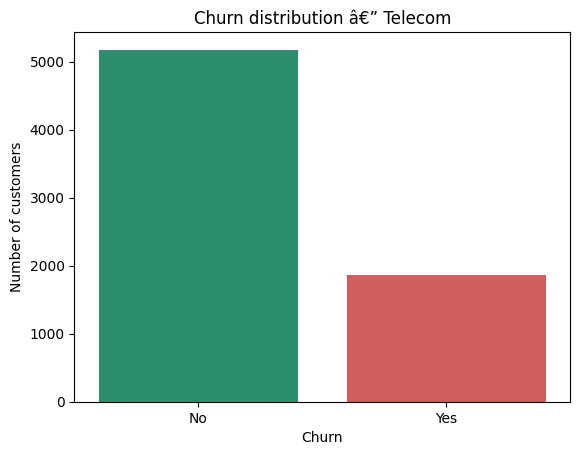

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True)*100

print("Churn counts:\n", churn_counts)
print(f"\nChurn = Yes : {churn_pct['Yes']:.1f}%")
print(f"Churn = No  : {churn_pct['No']:.1f}%")

sns.countplot(x='Churn', data=df,
              palette=['#1D9E75','#E24B4A'])
plt.title('Churn distribution â€” Telecom')
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.savefig('outputs/plots/telecom/01_churn_dist.png',
            bbox_inches='tight')
plt.show()

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80


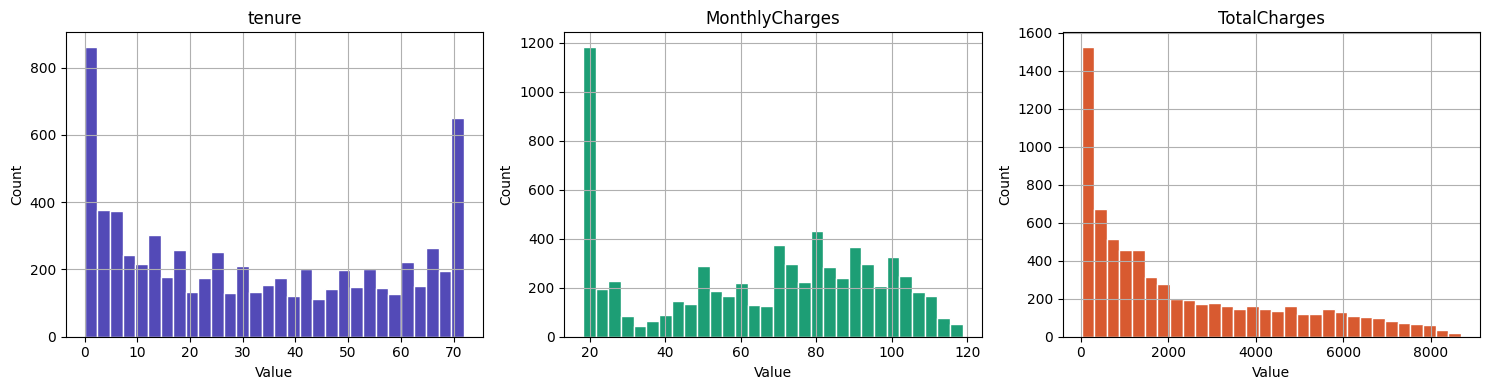

In [6]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']
print(df[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#534AB7','#1D9E75','#D85A30']

for ax, col, c in zip(axes, num_cols, colors):
    df[col].hist(bins=30, ax=ax, color=c, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('outputs/plots/telecom/02_numerical_dists.png',
            bbox_inches='tight')
plt.show()


Contract (3 unique):
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService (3 unique):
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod (4 unique):
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

gender (2 unique):
gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen (2 unique):
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner (2 unique):
Partner
No     3641
Yes    3402
Name: count, dtype: int64


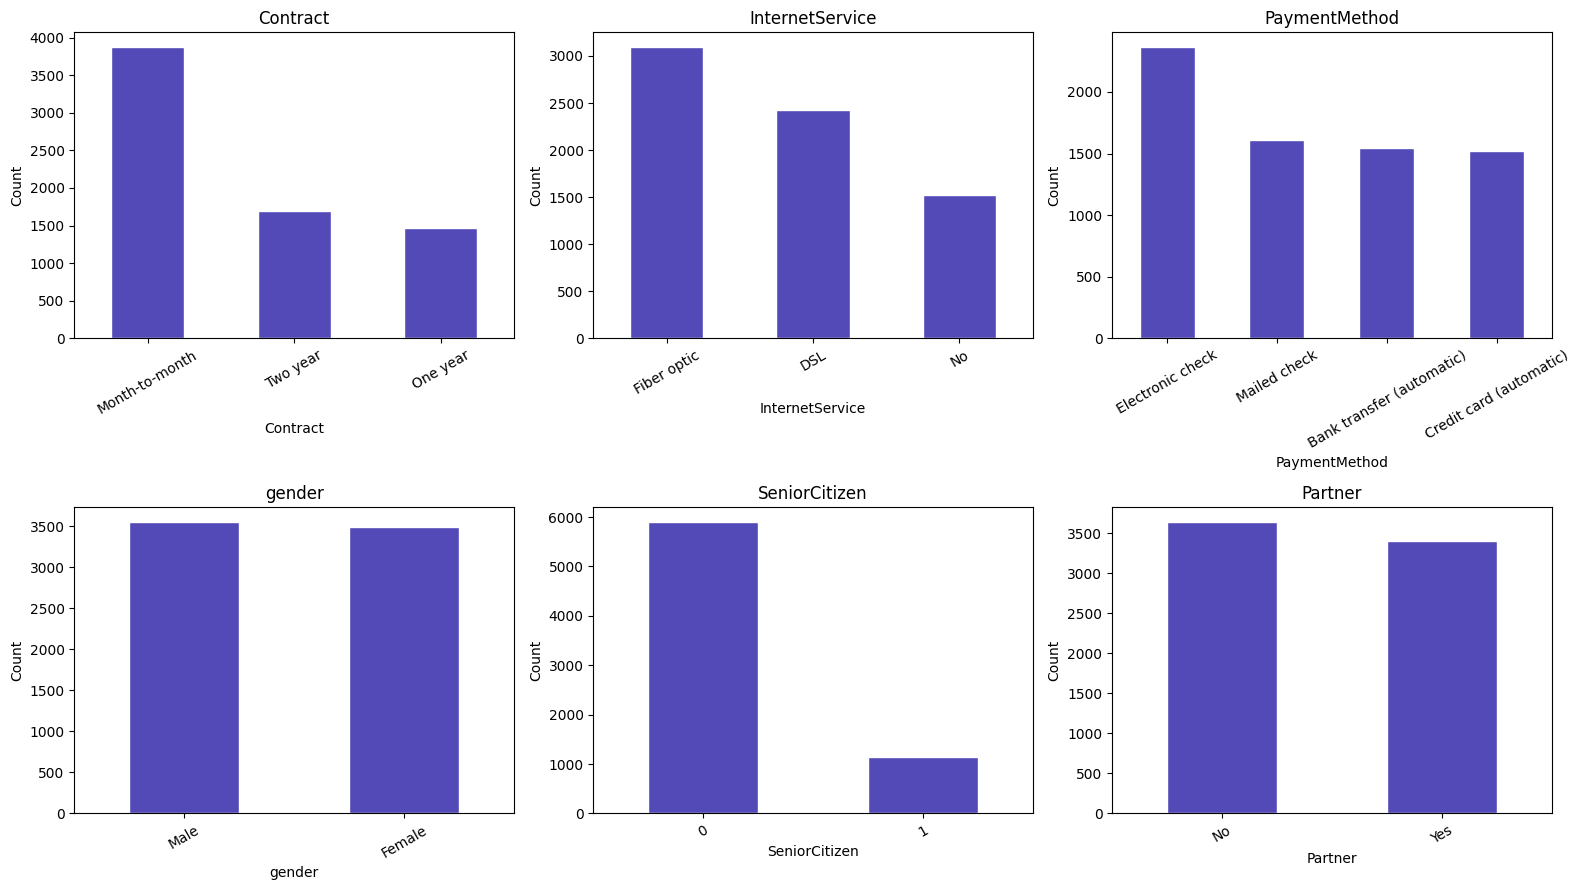

In [7]:
cat_cols = ['Contract','InternetService',
            'PaymentMethod','gender',
            'SeniorCitizen','Partner']

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (ax, col) in enumerate(
        zip(axes.flatten(), cat_cols)):
    df[col].value_counts().plot(
        kind='bar', ax=ax,
        color='#534AB7', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('outputs/plots/telecom/03_categorical_dists.png',
            bbox_inches='tight')
plt.show()

In [8]:
cat_features = ['Contract','InternetService',
                'TechSupport','PaymentMethod',
                'SeniorCitizen','Partner']

for col in cat_features:
    print(f"\nChurn rate by {col}:")
    rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).round(1)
    print(rate)
    print("-"*35)


Churn rate by Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64
-----------------------------------

Churn rate by InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64
-----------------------------------

Churn rate by TechSupport:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64
-----------------------------------

Churn rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64
-----------------------------------

Churn rate by SeniorCitizen:
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64
-----------------------------------

Churn rate by Partner:
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64
-----------------

In [9]:
print("Mean values by Churn group:\n")
print(df.groupby('Churn')[
    ['tenure','MonthlyCharges','TotalCharges']
].mean().round(2))

Mean values by Churn group:

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2555.34
Yes     17.98           74.44       1531.80


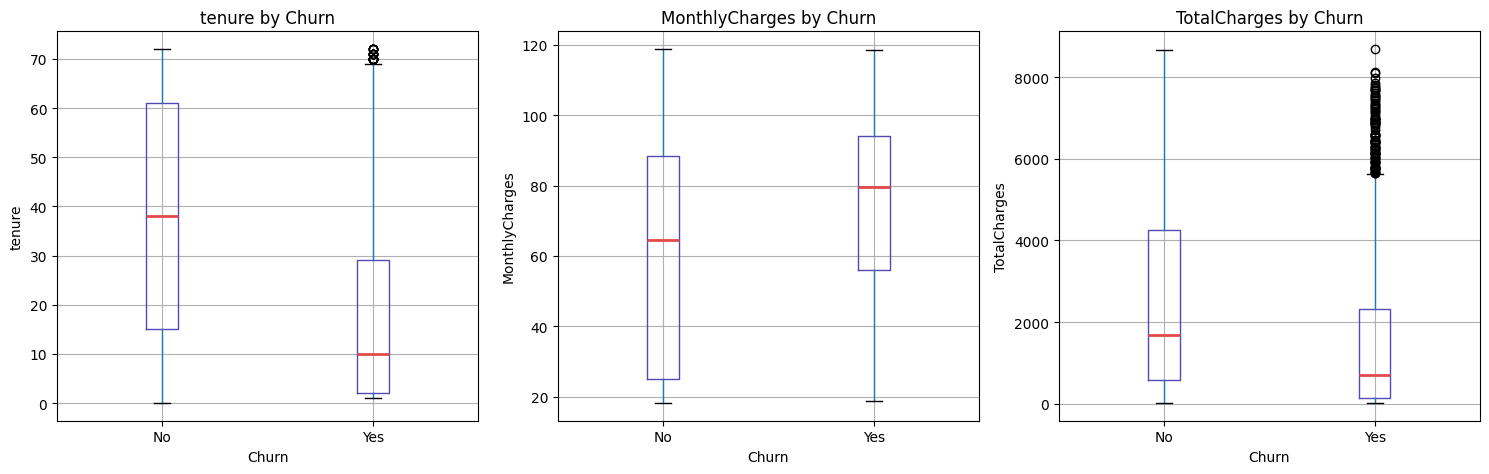

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes,
        ['tenure','MonthlyCharges','TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='#534AB7'),
               medianprops=dict(color='#E24B4A',
                                linewidth=2))
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/plots/telecom/05_num_vs_churn.png',
            bbox_inches='tight')
plt.show()